# MFA Analysis 

Visualizes results from `intrinsic_dims.pt` and `gaussian_overlap.pt`.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

experiment_name = os.environ.get("DALG_VIS_EXPERIMENT_NAME", "32000_17")
OUT = Path(os.environ.get(
    "DALG_VIS_OUT",
    f"/u/dssc/zenocosini/decomposing-activations-local-geometry/output/experiments/{experiment_name}",
))
PLOT_OUT = OUT / "plot"
PLOT_OUT.mkdir(exist_ok=True)

dims_data = torch.load(OUT / "intrinsic_dims.pt", weights_only=False)
ov_data   = torch.load(OUT / "gaussian_overlap.pt", weights_only=False)

cluster_sizes  = dims_data["cluster_sizes"]    # (K,)
min_cluster_size = int(os.environ.get("DALG_VIS_MIN_CLUSTER_SIZE", "1000"))
mask = ~(cluster_sizes < min_cluster_size)
max_components = int(os.environ.get("DALG_VIS_MAX_COMPONENTS", "0") or "0")
if max_components > 0 and int(mask.sum().item()) > max_components:
    candidates = torch.nonzero(mask, as_tuple=False).flatten()
    selected = candidates[torch.topk(cluster_sizes[candidates], k=max_components).indices].sort().values
    sampled_mask = torch.zeros_like(mask, dtype=torch.bool)
    sampled_mask[selected] = True
    print(f"Visualization restricted to top {max_components} clusters by size "
          f"out of {int(mask.sum().item())} clusters with size >= {min_cluster_size}")
    mask = sampled_mask
variance_mask = mask.clone()
for idx, (v, keep) in enumerate(zip(dims_data["cluster_variances"], mask.detach().cpu().tolist())):
    if keep and v.numel() == 0:
        variance_mask[idx] = False
if int(variance_mask.sum().item()) < int(mask.sum().item()):
    print(f"Excluded {int(mask.sum().item() - variance_mask.sum().item())} clusters with empty variance spectra")
mask = variance_mask

intrinsic_dims = dims_data["intrinsic_dims"][mask]   # (K,)
selected_variances = [v[:1000] for v, keep in zip(dims_data["cluster_variances"], mask.detach().cpu().tolist()) if keep]
variance_plot_dims = max(v.numel() for v in selected_variances)
cluster_variances = torch.stack([
    torch.cat([v, v.new_zeros(variance_plot_dims - v.numel())]) if v.numel() < variance_plot_dims else v
    for v in selected_variances
])
K     = dims_data["K"]
rank  = dims_data["rank"]
D     = dims_data["D"]
thr   = dims_data["variance_threshold"]

kl_sym  = ov_data["kl_sym"][mask][:,mask]   # (K, K)
db      = ov_data["db"][mask][:,mask]
db_mean = ov_data["db_mean"][mask][:,mask]
db_cov  = ov_data["db_cov"][mask][:,mask]
bc      = ov_data["bc"][mask][:,mask]

# Upper-triangle flat arrays (off-diagonal pairs)
effective_K = mask.sum().item()
idx_i, idx_j = torch.triu_indices(effective_K, effective_K, offset=1)
kl_flat  = kl_sym[idx_i, idx_j]
db_flat  = db[idx_i, idx_j]
dbm_flat = db_mean[idx_i, idx_j]
dbc_flat = db_cov[idx_i, idx_j]
bc_flat  = bc[idx_i, idx_j]

valid = intrinsic_dims > 0
print(f"K={K}  rank(q)={rank}  D={D}  variance_threshold={thr}")
print(f"Clusters with data: {valid.sum().item()} / {K}")
print(f"Intrinsic dim — mean={intrinsic_dims[valid].float().mean():.1f}  "
      f"median={intrinsic_dims[valid].float().median():.1f}  "
      f"min={intrinsic_dims[valid].min().item()}  max={intrinsic_dims[valid].max().item()}")

K=32000  rank(q)=10  D=2048  variance_threshold=0.9
Clusters with data: 22926 / 32000
Intrinsic dim — mean=209.0  median=210.0  min=4  max=736


## 1. Intrinsic Dimensionality

In [2]:
# --- Preprocess ---
cumsum_vars = (cluster_variances.cumsum(dim=1) / 
 cluster_variances.sum(dim=1, keepdim=True)).mean(dim=0) # (K, D) cumulative variance ratios


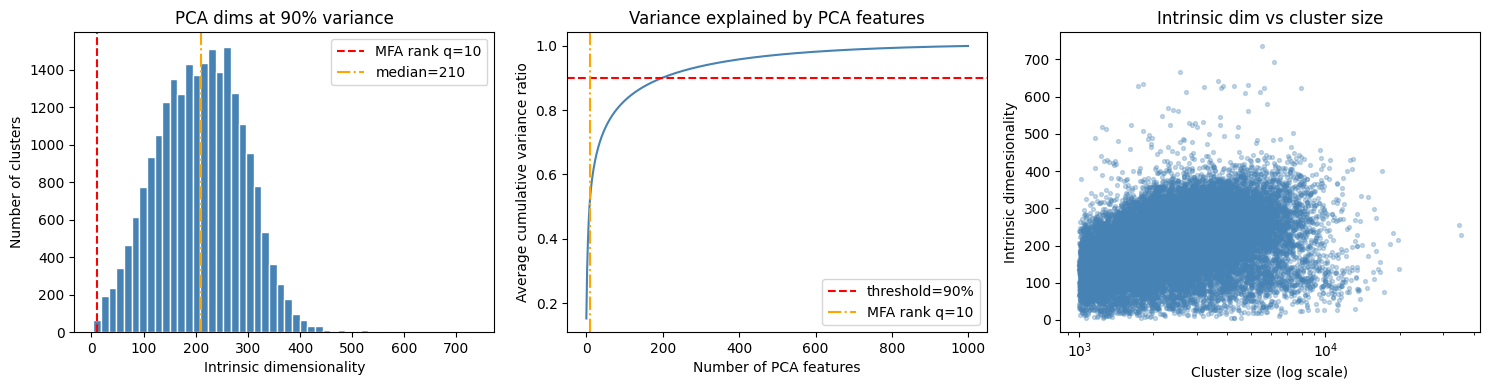

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram of intrinsic dims ---
ax = axes[0]
vals_id = intrinsic_dims.numpy()
ax.hist(vals_id, bins=50, color="steelblue", edgecolor="white")
ax.axvline(rank, color="red", linestyle="--", label=f"MFA rank q={rank}")
ax.axvline(float(np.median(vals_id)), color="orange", linestyle="-.", label=f"median={np.median(vals_id):.0f}")
ax.set_xlabel("Intrinsic dimensionality")
ax.set_ylabel("Number of clusters")
ax.set_title(f"PCA dims at {thr*100:.0f}% variance")
ax.legend()

# --- Variance Explained by features ---
ax = axes[1]
vals = cumsum_vars.numpy()
ax.plot(vals, color="steelblue")
ax.axhline(thr, color="red", linestyle="--", label=f"threshold={thr*100:.0f}%")
ax.axvline(rank, color="orange", linestyle="-.", label=f"MFA rank q={rank}")
ax.set_xlabel("Number of PCA features")
ax.set_ylabel("Average cumulative variance ratio")
ax.set_title("Variance explained by PCA features")
ax.legend()
# --- Intrinsic dim vs cluster size ---
ax = axes[2]
sizes = cluster_sizes[mask].numpy()
ax.scatter(sizes, vals_id, alpha=0.3, s=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Cluster size (log scale)")
ax.set_ylabel("Intrinsic dimensionality")
ax.set_title("Intrinsic dim vs cluster size")

plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_intrinsic_dims.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 2. Cluster Size Distribution

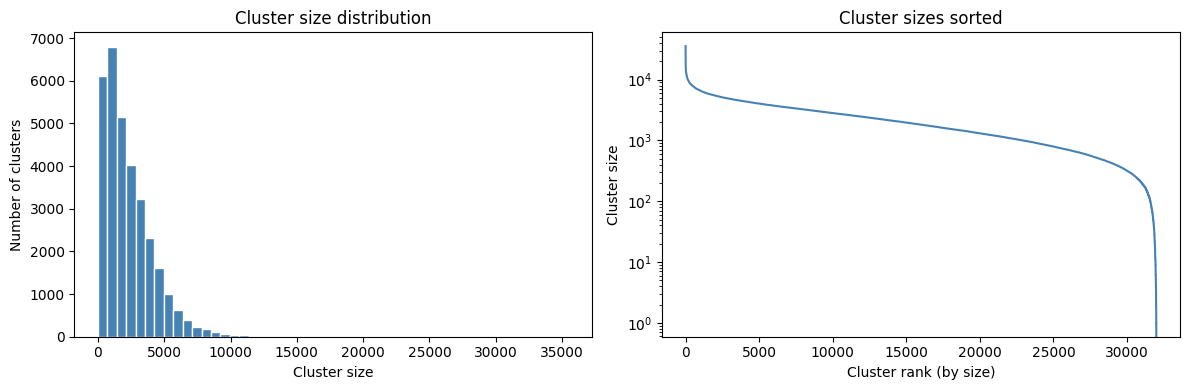

Cluster sizes — min=0  max=35514  mean=2302.7  median=1818.0
Empty clusters: 11


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(cluster_sizes.numpy(), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Cluster size")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster size distribution")

ax = axes[1]
sorted_sizes = np.sort(cluster_sizes.numpy())[::-1]
ax.plot(sorted_sizes, color="steelblue")
ax.set_xlabel("Cluster rank (by size)")
ax.set_ylabel("Cluster size")
ax.set_title("Cluster sizes sorted")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_cluster_sizes.pdf", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cluster sizes — min={cluster_sizes.min().item()}  max={cluster_sizes.max().item()}  "
      f"mean={cluster_sizes.float().mean():.1f}  median={cluster_sizes.float().median():.1f}")
print(f"Empty clusters: {(cluster_sizes == 0).sum().item()}")

## 3. Gaussian Overlap Metrics — Histograms

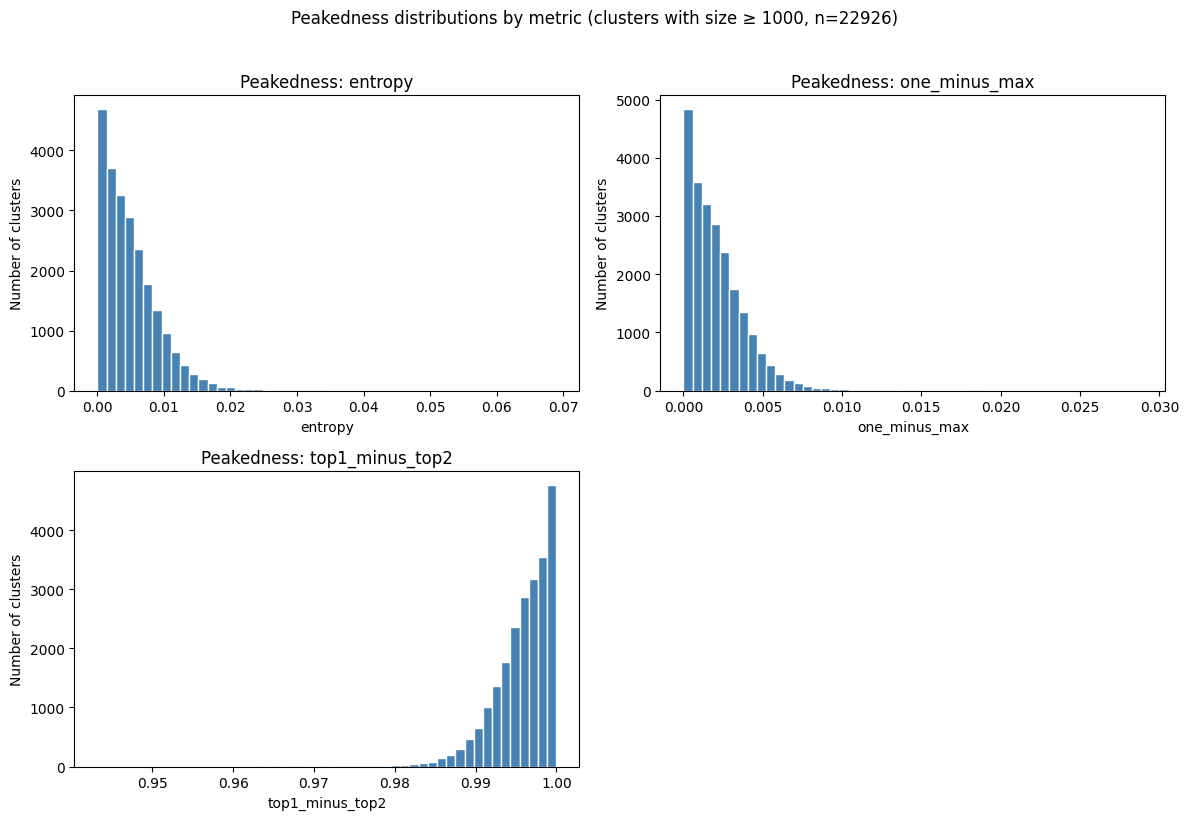

In [5]:
# --- Peakedness of each feature ----
peakedness_dict = dims_data["peakedness"]
metric_names = list(peakedness_dict.keys())

n_metrics = len(metric_names)
n_cols = 2
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax_i, metric_name in enumerate(metric_names):
    values = peakedness_dict[metric_name][mask].detach().cpu().numpy()
    axes[ax_i].hist(values, bins=50, color="steelblue", edgecolor="white")
    axes[ax_i].set_xlabel(metric_name)
    axes[ax_i].set_ylabel("Number of clusters")
    axes[ax_i].set_title(f"Peakedness: {metric_name}")

for ax_i in range(n_metrics, len(axes)):
    axes[ax_i].axis("off")


fig.suptitle(f"Peakedness distributions by metric (clusters with size ≥ 1000, n={effective_K})", y=1.02)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_peakedness.pdf", dpi=150, bbox_inches="tight")
plt.show()

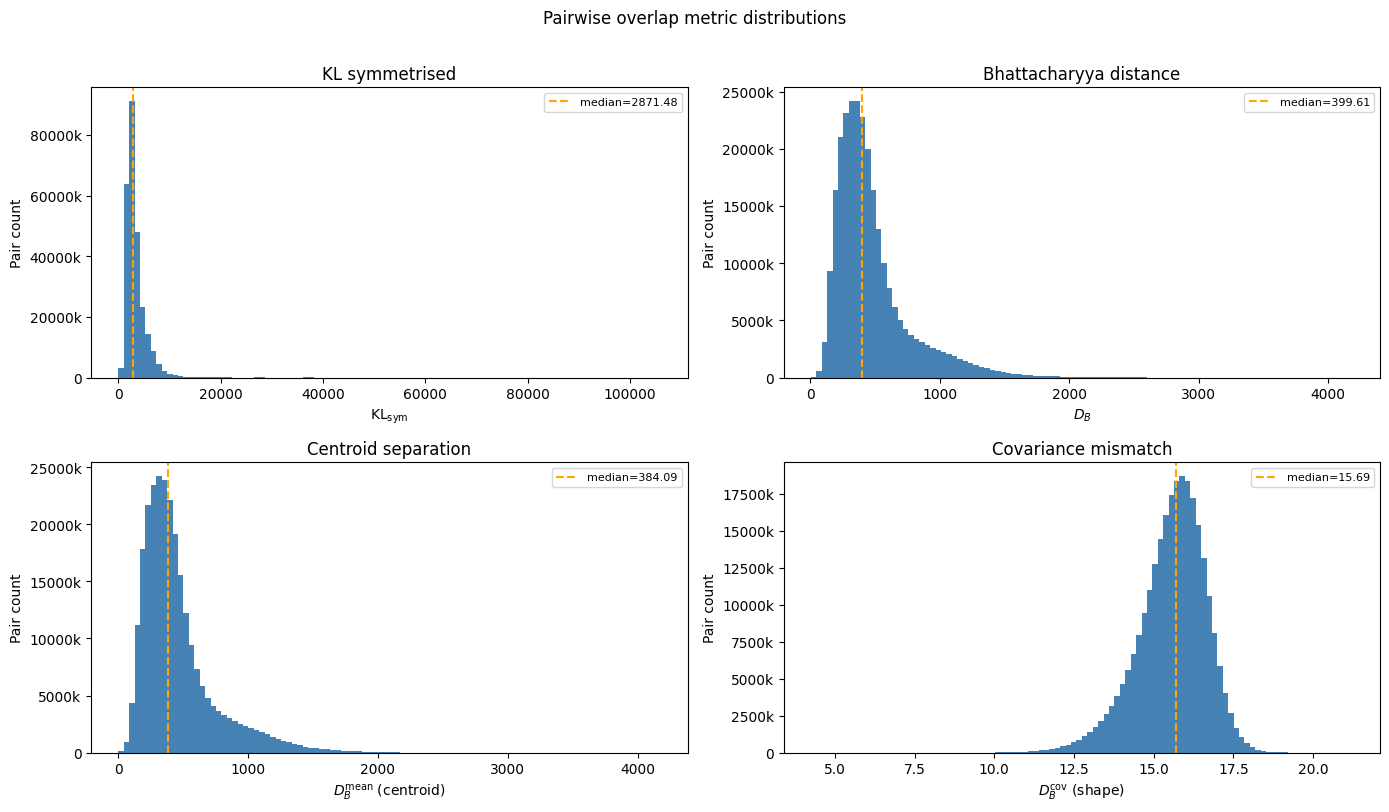

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

panels = [
    (axes[0, 0], kl_flat,  r"$\mathrm{KL}_{\mathrm{sym}}$",      "KL symmetrised"),
    (axes[0, 1], db_flat,  r"$D_B$",                               "Bhattacharyya distance"),
    (axes[1, 0], dbm_flat, r"$D_B^{\mathrm{mean}}$ (centroid)",   "Centroid separation"),
    (axes[1, 1], dbc_flat, r"$D_B^{\mathrm{cov}}$ (shape)",       "Covariance mismatch"),
]

for ax, flat, xlabel, title in panels:
    vals = flat.numpy()
    ax.hist(vals, bins=100, color="steelblue", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pair count")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else str(int(x))))
    med = float(np.median(vals))
    ax.axvline(med, color="orange", linestyle="--", label=f"median={med:.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Pairwise Gaussian overlap metric distributions", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_histograms.pdf", dpi=150, bbox_inches="tight")
plt.show()

## 4. Gaussian Overlap Heatmaps (hierarchically ordered)


In [7]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Order heatmaps by average-linkage clustering on KL_sym, matching the original notebook.
# Clip numerical negatives before converting to scipy's condensed distance format.
kl_np = kl_sym.numpy()
kl_np = np.clip(kl_np, 0, None)
np.fill_diagonal(kl_np, 0)

condensed_raw = squareform(kl_np, checks=False)
positive_kl = condensed_raw[condensed_raw > 0]

condensed = condensed_raw
if positive_kl.size:
    condensed = np.clip(condensed, 0, np.percentile(positive_kl, 99))

Z = linkage(condensed, method="average")
order = leaves_list(Z)

print(f"Hierarchical ordering computed over {effective_K} components")
if positive_kl.size:
    print(
        "Raw KL_sym percentiles: "
        f"50={np.percentile(positive_kl, 50):.2f}, "
        f"90={np.percentile(positive_kl, 90):.2f}, "
        f"99={np.percentile(positive_kl, 99):.2f}"
    )


Hierarchical ordering computed over 22926 components
Raw KL_sym percentiles: 50=2871.48, 90=5807.86, 99=10347.13


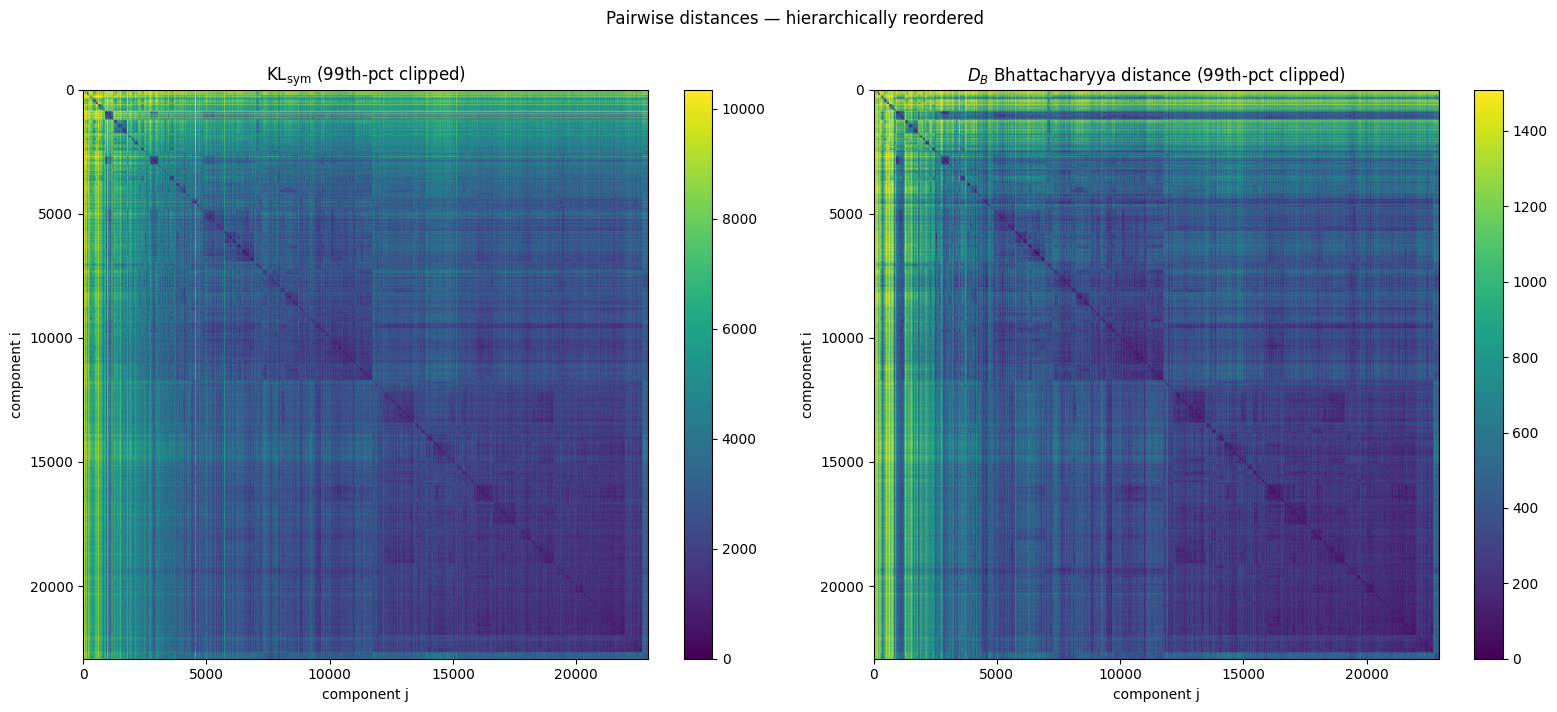

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# TODO I am clipping just the legend it doesn't make sense
# KL_sym heatmap
ax = axes[0]
mat = kl_sym[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$\mathrm{KL}_{\mathrm{sym}}$ (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# D_B heatmap
ax = axes[1]
mat = db[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$D_B$ Bhattacharyya distance (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Pairwise distances — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_heatmaps_dist.pdf", dpi=150, bbox_inches="tight")
plt.show()

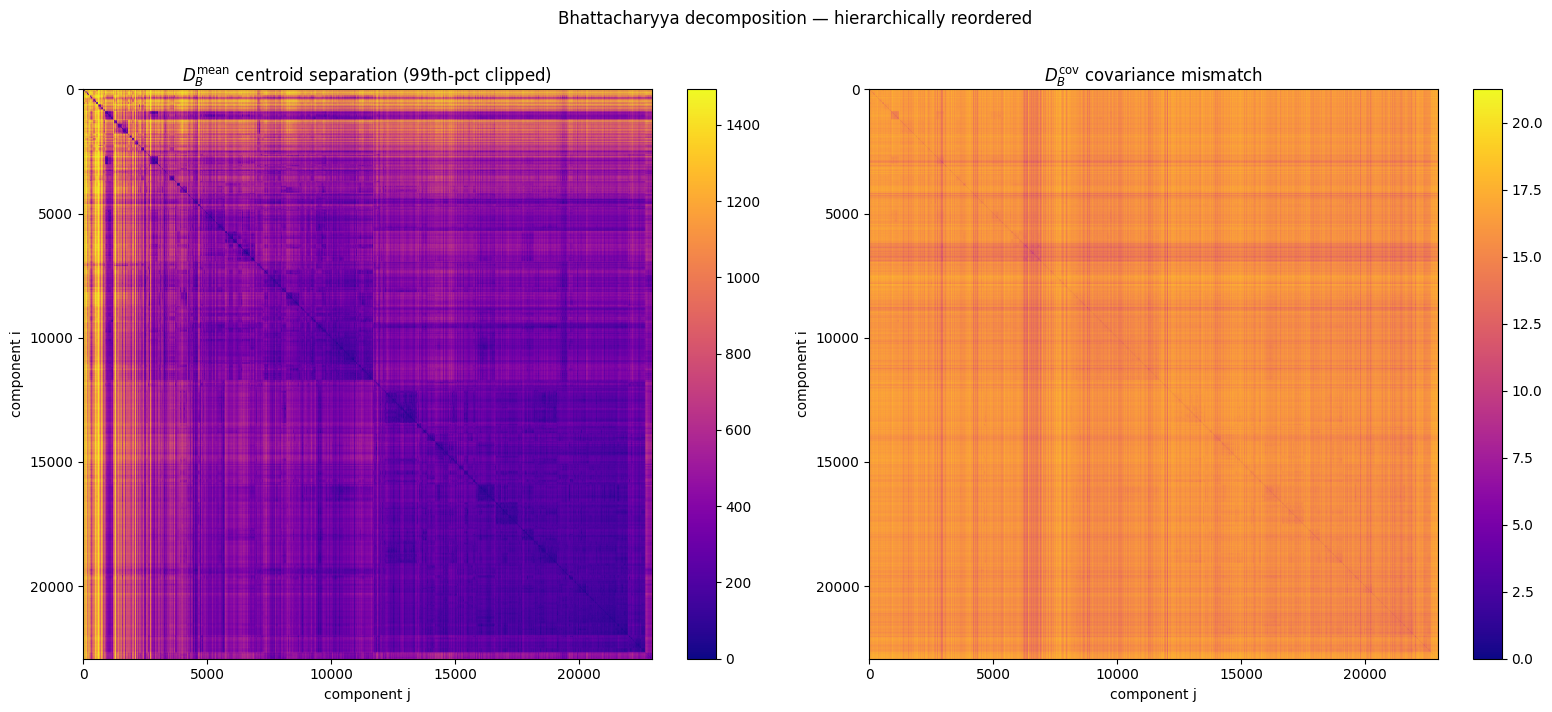

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# TODO I am clipping just the legend it doesn't make sense
# db_mean
ax = axes[0]
mat = db_mean[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 99)
im = ax.imshow(mat, aspect="auto", cmap="plasma", vmin=0, vmax=vmax)
ax.set_title(r"$D_B^{\mathrm{mean}}$ centroid separation (99th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# db_cov
ax = axes[1]
mat = db_cov[order][:, order].numpy()
im = ax.imshow(mat, aspect="auto", cmap="plasma")
ax.set_title(r"$D_B^{\mathrm{cov}}$ covariance mismatch")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Bhattacharyya decomposition — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_OUT / f"{experiment_name}_gaussian_overlap_heatmaps_bhatt.pdf", dpi=150, bbox_inches="tight")
plt.show()